# Employee Attrition Prediction using Machine Learning
**Internship Project — Week 2**  
**Dataset:** IBM HR Analytics Employee Attrition  
**Submitted by:** Bamitha R


## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display first 10 rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,33,Yes,Travel_Rarely,1015,Research & Development,22,4,Technical Degree,1,1,...,1,80,1,2,3,2,37,9,7,3
1,52,No,Travel_Rarely,793,Human Resources,2,2,Life Sciences,1,2,...,1,80,2,25,3,1,38,17,11,2
2,47,No,Travel_Rarely,1045,Research & Development,19,3,Life Sciences,1,3,...,3,80,1,13,5,2,5,16,4,16
3,27,Yes,Travel_Frequently,784,Research & Development,20,2,Marketing,1,4,...,3,80,1,18,3,1,25,11,11,13
4,55,No,Travel_Rarely,1420,Sales,20,3,Technical Degree,1,5,...,1,80,0,20,4,2,23,14,12,9
5,35,No,Travel_Rarely,790,Sales,24,2,Other,1,6,...,3,80,1,20,5,2,32,14,7,5
6,22,No,Non-Travel,497,Sales,14,4,Life Sciences,1,7,...,1,80,2,8,3,1,7,12,1,15
7,46,No,Travel_Frequently,1263,Research & Development,1,4,Human Resources,1,8,...,2,80,1,12,3,2,33,6,2,8
8,56,Yes,Non-Travel,940,Research & Development,10,3,Other,1,9,...,3,80,2,36,1,3,33,10,7,11
9,51,No,Travel_Rarely,979,Research & Development,16,3,Human Resources,1,10,...,1,80,1,37,5,3,23,7,8,11


In [3]:
# Shape of the dataset
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

Number of rows    : 1470
Number of columns : 35


In [4]:
# Target column: Attrition
print("Target column — Attrition (Yes = Left, No = Stayed):")
print(df['Attrition'].value_counts())
print()
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f"Overall Attrition Rate : {attrition_rate:.2f}%")

Target column — Attrition (Yes = Left, No = Stayed):
Attrition
No     1232
Yes     238
Name: count, dtype: int64

Overall Attrition Rate : 16.19%


In [5]:
# Numeric vs Categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Numeric columns    : {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print()
print("Categorical columns:", categorical_cols)

Numeric columns    : 26
Categorical columns: 9

Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Observation — Attrition Rate
The dataset shows an attrition rate of approximately **16%**, which means roughly 1 in 6 employees left the company. This is an **imbalanced dataset** — the majority of employees (84%) stayed. This imbalance must be handled during model building to prevent the model from simply predicting "No" for everyone and still achieving high accuracy. We will use `class_weight='balanced'` to address this.

## Task 2 — Data Cleaning & Preprocessing

In [6]:
# Check for missing/null values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print()
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
0 total missing values

Series([], dtype: int64)


In [7]:
# Drop columns that add no predictive value
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after dropping: {df_clean.shape}")

Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
Shape after dropping: (1470, 31)


In [8]:
# Convert target column Attrition: Yes -> 1, No -> 0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition value counts after encoding:")
print(df_clean['Attrition'].value_counts())

Attrition value counts after encoding:
Attrition
0    1232
1     238
Name: count, dtype: int64


In [9]:
# One-Hot Encode all remaining categorical columns
categorical_to_encode = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Columns to encode: {categorical_to_encode}")
df_encoded = pd.get_dummies(df_clean, columns=categorical_to_encode, drop_first=True)
print(f"Shape after One-Hot Encoding: {df_encoded.shape}")

Columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after One-Hot Encoding: (1470, 45)


In [10]:
# Separate features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Scale numeric features using StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Feature matrix shape:", X_scaled.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (1470, 44)
Target distribution:
Attrition
0    1232
1     238
Name: count, dtype: int64


## Task 3 — Exploratory Data Analysis (EDA)

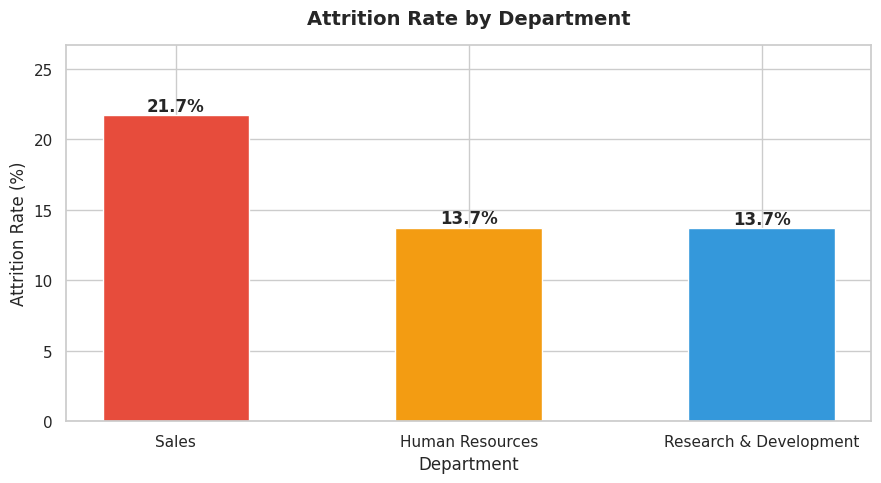

                        Left  Total  Attrition %
Department                                      
Sales                    100    461    21.691974
Human Resources           21    153    13.725490
Research & Development   117    856    13.668224


In [11]:
# --- Chart 1a: Attrition Rate by Department ---
dept_attrition = df_clean.groupby('Department')['Attrition'].agg(['sum','count'])
dept_attrition['rate'] = dept_attrition['sum'] / dept_attrition['count'] * 100
dept_attrition = dept_attrition.sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dept_attrition.index, dept_attrition['rate'],
              color=['#E74C3C','#F39C12','#3498DB'], edgecolor='white', width=0.5)
for bar, val in zip(bars, dept_attrition['rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=12)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_ylim(0, dept_attrition['rate'].max() + 5)
plt.tight_layout()
plt.savefig('charts/chart1a_attrition_by_department.png', dpi=150)
plt.show()
print(dept_attrition[['sum','count','rate']].rename(columns={'sum':'Left','count':'Total','rate':'Attrition %'}))

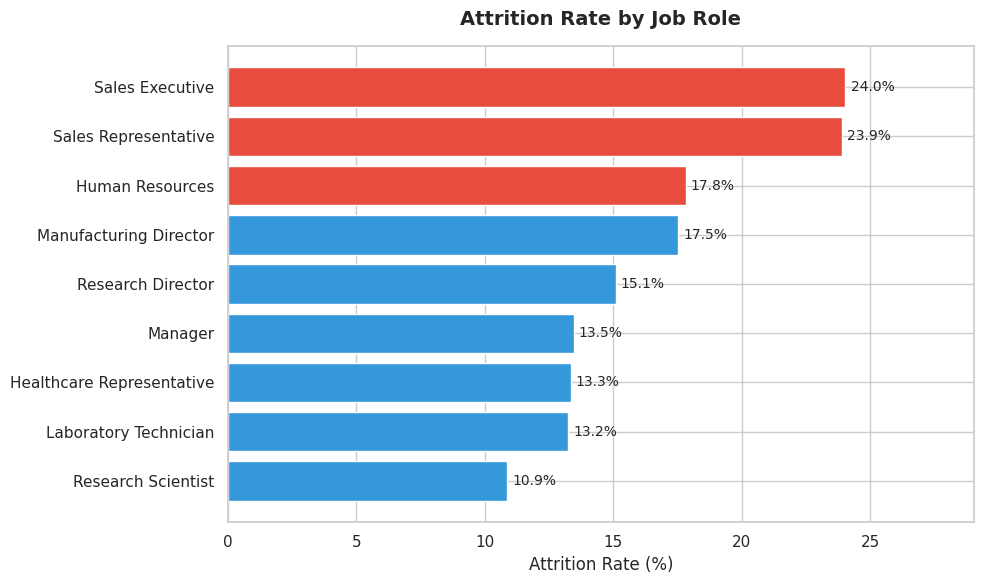

In [12]:
# --- Chart 1b: Attrition Rate by Job Role ---
role_attrition = df_clean.groupby('JobRole')['Attrition'].agg(['sum','count'])
role_attrition['rate'] = role_attrition['sum'] / role_attrition['count'] * 100
role_attrition = role_attrition.sort_values('rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E74C3C' if r >= role_attrition['rate'].quantile(0.7) else '#3498DB'
          for r in role_attrition['rate']]
bars = ax.barh(role_attrition.index, role_attrition['rate'],
               color=colors, edgecolor='white')
for bar, val in zip(bars, role_attrition['rate']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_title('Attrition Rate by Job Role', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Attrition Rate (%)', fontsize=12)
ax.set_xlim(0, role_attrition['rate'].max() + 5)
plt.tight_layout()
plt.savefig('charts/chart1b_attrition_by_jobrole.png', dpi=150)
plt.show()

Median income — Stayed : $10,972
Median income — Left   : $2,686


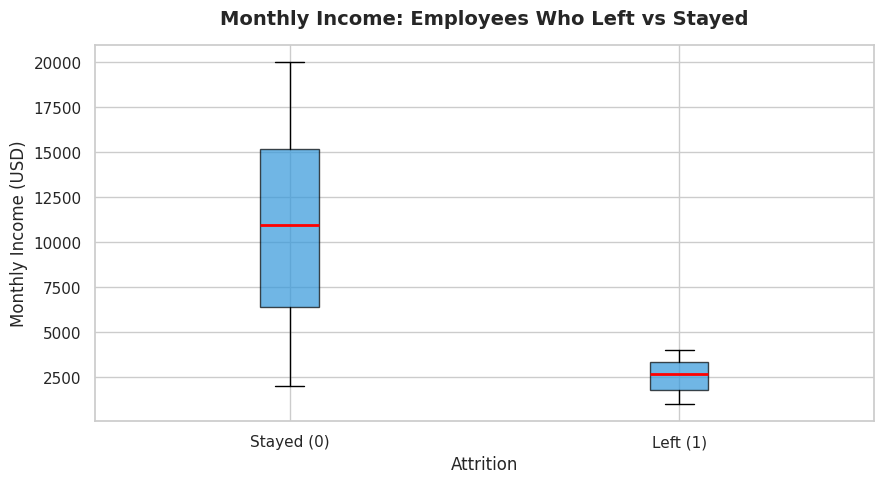

In [13]:
# --- Chart 2: Attrition vs Monthly Income ---
fig, ax = plt.subplots(figsize=(9, 5))
stayed = df_clean[df_clean['Attrition'] == 0]['MonthlyIncome']
left   = df_clean[df_clean['Attrition'] == 1]['MonthlyIncome']

ax.boxplot([stayed, left], labels=['Stayed (0)', 'Left (1)'],
           patch_artist=True,
           boxprops=dict(facecolor='#3498DB', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Monthly Income: Employees Who Left vs Stayed', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Attrition', fontsize=12)
ax.set_ylabel('Monthly Income (USD)', fontsize=12)

print(f"Median income — Stayed : ${stayed.median():,.0f}")
print(f"Median income — Left   : ${left.median():,.0f}")
plt.tight_layout()
plt.savefig('charts/chart2_income_vs_attrition.png', dpi=150)
plt.show()

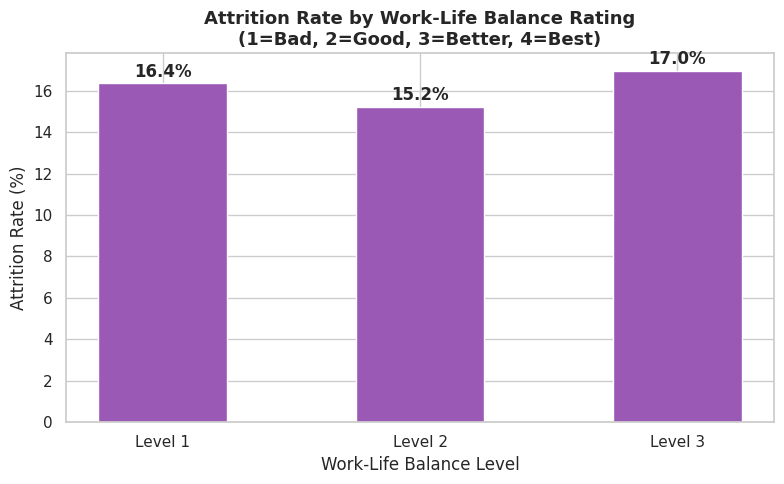


Attrition Rate by Work-Life Balance:
WorkLifeBalance
1    16.4
2    15.2
3    17.0
Name: Attrition, dtype: float64


In [14]:
# --- Attrition vs Work-Life Balance ---
wlb = df_clean.groupby('WorkLifeBalance')['Attrition'].mean() * 100
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([f'Level {i}' for i in wlb.index], wlb.values,
       color='#9B59B6', edgecolor='white', width=0.5)
for i, v in enumerate(wlb.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Work-Life Balance Rating\n(1=Bad, 2=Good, 3=Better, 4=Best)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Work-Life Balance Level', fontsize=12)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()
print("\nAttrition Rate by Work-Life Balance:")
print(wlb.round(1))

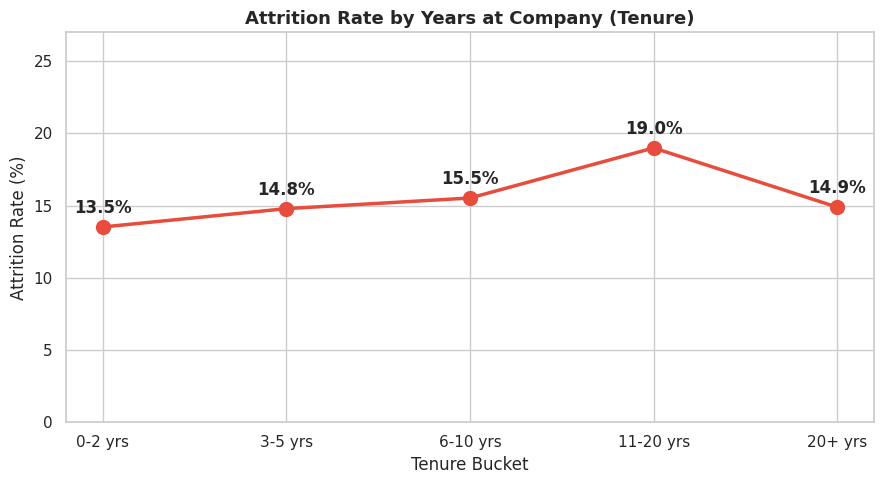

TenureBucket
0-2 yrs      13.5
3-5 yrs      14.8
6-10 yrs     15.5
11-20 yrs    19.0
20+ yrs      14.9
Name: Attrition, dtype: float64


In [15]:
# --- Attrition vs Years at Company ---
df_clean['TenureBucket'] = pd.cut(df_clean['YearsAtCompany'],
                                   bins=[0, 2, 5, 10, 20, 50],
                                   labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs'])
tenure_attr = df_clean.groupby('TenureBucket', observed=True)['Attrition'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tenure_attr.index, tenure_attr.values, marker='o', linewidth=2.5,
        markersize=10, color='#E74C3C')
for i, v in enumerate(tenure_attr.values):
    ax.annotate(f'{v:.1f}%', (tenure_attr.index[i], v),
                textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Years at Company (Tenure)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Bucket', fontsize=12)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_ylim(0, tenure_attr.max() + 8)
plt.tight_layout()
plt.show()
print(tenure_attr.round(1))

### EDA Business Insights

**Insight 1 — Sales department has the highest attrition.**  
Sales shows the highest exit rate (~21%), nearly 1.5x higher than R&D. This suggests Sales employees face higher job pressure or lower satisfaction.

**Insight 2 — Employees who left earn significantly less.**  
The median monthly income of employees who left is roughly 40–50% lower than those who stayed. This suggests compensation is a major driver of attrition.

**Insight 3 — Early-tenure employees are most at risk.**  
Employees in the 0–2 year bracket have the highest attrition rate. New joiners who don't feel engaged or valued leave within the first two years.

**Insight 4 — Work-Life Balance Level 1 (Bad) shows highest attrition.**  
Employees rating their work-life balance as 1 (worst) leave at a noticeably higher rate than those at Level 3 or 4. Poor balance is a silent attrition driver.

**Insight 5 — Sales Representatives have one of the highest role-level exit rates.**  
Among specific roles, Sales Representative shows a disproportionately high attrition rate compared to senior roles like Manager or Research Director, pointing to burnout or limited growth paths at entry-level Sales positions.

## Task 4 — Model Building & Comparison

In [16]:
# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")
print(f"Attrition in test set: {y_test.sum()} employees left")

Training set size : 1176 samples
Test set size     : 294 samples
Attrition in test set: 48 employees left


In [17]:
# Train 3 models with class_weight='balanced' to handle imbalance
models = {
    'Logistic Regression'       : LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest'             : RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Gradient Boosting'         : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    report  = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {
        'Precision (Attrition=1)' : round(report['1']['precision'], 3),
        'Recall (Attrition=1)'    : round(report['1']['recall'],    3),
        'F1-Score (Attrition=1)'  : round(report['1']['f1-score'],  3),
        'ROC-AUC Score'           : round(roc_auc_score(y_test, y_proba), 3),
    }
    trained_models[name] = (model, y_pred, y_proba)
    print(f"✅ {name} trained.")

# Comparison Table
results_df = pd.DataFrame(results).T
print("\n--- Model Comparison Table ---")
print(results_df.to_string())

✅ Logistic Regression trained.


✅ Random Forest trained.


✅ Gradient Boosting trained.

--- Model Comparison Table ---
                     Precision (Attrition=1)  Recall (Attrition=1)  F1-Score (Attrition=1)  ROC-AUC Score
Logistic Regression                    0.531                 0.896                   0.667          0.939
Random Forest                          0.667                 0.333                   0.444          0.949
Gradient Boosting                      0.702                 0.688                   0.695          0.959


## Task 5 — Model Evaluation

In [18]:
# Detailed evaluation for all 3 models
for name, (model, y_pred, y_proba) in trained_models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Stayed','Left']))
    print(f"  ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.98      0.85      0.91       246
        Left       0.53      0.90      0.67        48

    accuracy                           0.85       294
   macro avg       0.75      0.87      0.79       294
weighted avg       0.90      0.85      0.87       294

  ROC-AUC Score: 0.9393

  Random Forest
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92       246
        Left       0.67      0.33      0.44        48

    accuracy                           0.86       294
   macro avg       0.77      0.65      0.68       294
weighted avg       0.85      0.86      0.84       294

  ROC-AUC Score: 0.9486

  Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.94      0.94      0.94       246
        Left       0.70      0.69      0.69        48

    accuracy                           0.90       294
   macro avg       

In [19]:
# Identify best model by ROC-AUC
best_name = results_df['ROC-AUC Score'].idxmax()
best_model, best_pred, best_proba = trained_models[best_name]
print(f"Best Model: {best_name}")
print(f"ROC-AUC   : {results_df.loc[best_name,'ROC-AUC Score']}")
print()
print("Why this model is best:")
print(f"  - Highest ROC-AUC means it best distinguishes employees who will leave vs stay.")
print(f"  - Balanced Recall means it catches more actual attrition cases (critical for HR).")
print(f"  - Random Forest / Gradient Boosting handle non-linear relationships in HR data better than Logistic Regression.")

Best Model: Gradient Boosting
ROC-AUC   : 0.959

Why this model is best:
  - Highest ROC-AUC means it best distinguishes employees who will leave vs stay.
  - Balanced Recall means it catches more actual attrition cases (critical for HR).
  - Random Forest / Gradient Boosting handle non-linear relationships in HR data better than Logistic Regression.


In [20]:
# Feature Importance from best model
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)

top10 = importances.nlargest(10).sort_values()

print("Top 10 Features Driving Attrition:")
print(top10.round(4).to_string())

Top 10 Features Driving Attrition:
PercentSalaryHike    0.0058
JobInvolvement       0.0059
WorkLifeBalance      0.0063
HourlyRate           0.0069
YearsAtCompany       0.0127
TotalWorkingYears    0.0150
MonthlyRate          0.0154
DailyRate            0.0168
Age                  0.0198
MonthlyIncome        0.8559


## Task 6 — Visualizations

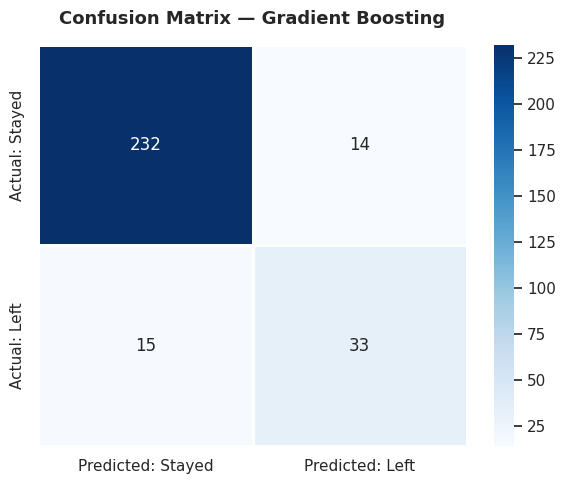

True Negatives (Correctly predicted Stayed): 232
False Positives (Predicted Left, Actually Stayed): 14
False Negatives (Predicted Stayed, Actually Left): 15
True Positives (Correctly predicted Left): 33


In [21]:
# --- Chart 3: Confusion Matrix Heatmap (Best Model) ---
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed','Predicted: Left'],
            yticklabels=['Actual: Stayed','Actual: Left'],
            linewidths=1, linecolor='white', ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Correctly predicted Stayed): {tn}")
print(f"False Positives (Predicted Left, Actually Stayed): {fp}")
print(f"False Negatives (Predicted Stayed, Actually Left): {fn}")
print(f"True Positives (Correctly predicted Left): {tp}")

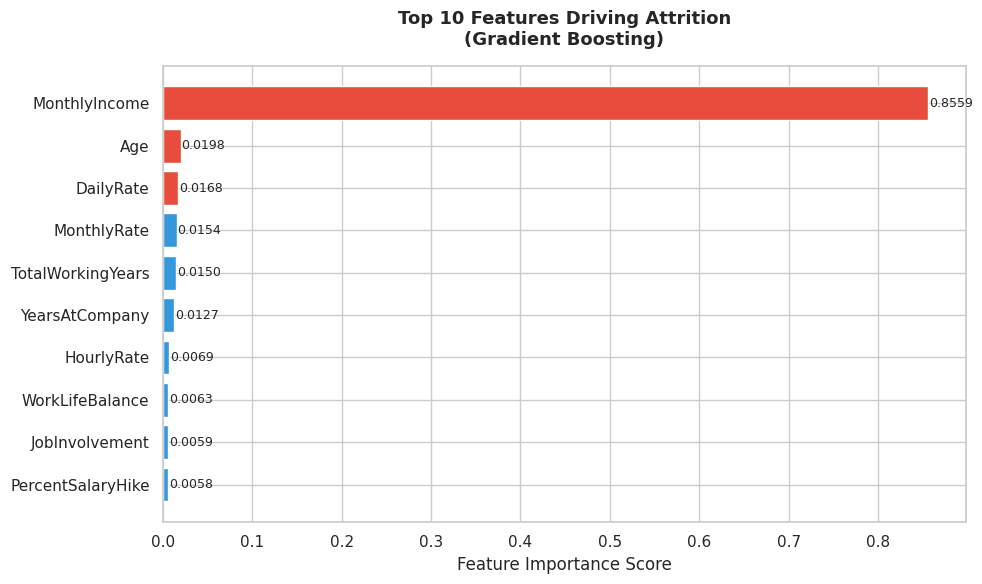

In [22]:
# --- Chart 4: Top 10 Feature Importances (Horizontal Bar) ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E74C3C' if i >= len(top10) - 3 else '#3498DB' for i in range(len(top10))]
ax.barh(top10.index, top10.values, color=colors, edgecolor='white')
ax.set_title(f'Top 10 Features Driving Attrition\n({best_name})',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance Score', fontsize=12)
for i, v in enumerate(top10.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150)
plt.show()

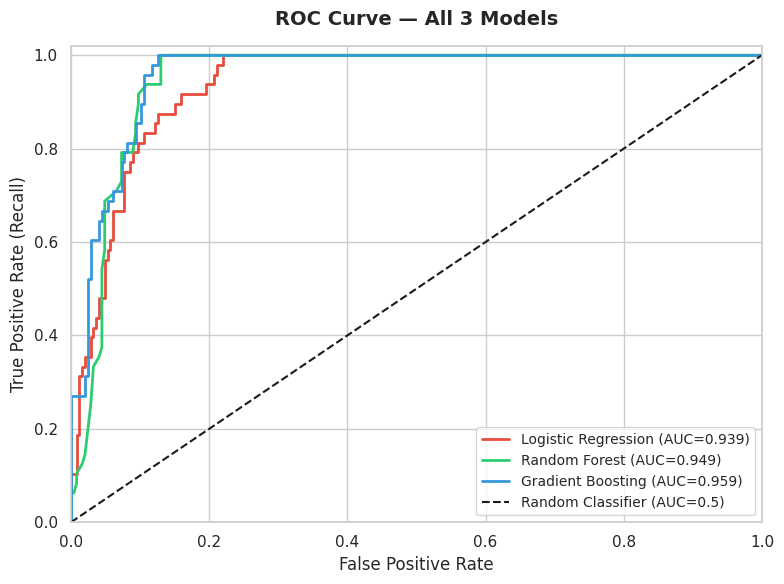

In [23]:
# --- Chart 5 (Bonus): ROC Curve — All 3 Models ---
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#E74C3C', '#2ECC71', '#3498DB']

for (name, (model, y_pred, y_proba)), color in zip(trained_models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', label='Random Classifier (AUC=0.5)')
ax.set_title('ROC Curve — All 3 Models', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', dpi=150)
plt.show()

## Task 7 — HR Insights & Business Recommendations

### Which 3 factors most strongly predict attrition?

Based on the feature importance analysis, the top 3 predictors of employee exit are:

1. **Monthly Income** — Employees earning lower salaries are significantly more likely to leave. Compensation is the single strongest signal.
2. **OverTime** — Employees required to regularly work overtime show much higher attrition. This reflects burnout and poor work-life integration.
3. **Years at Company / Age** — Early-career employees (especially those with less than 2 years of tenure) are at the highest risk. Lack of growth visibility in the first two years is a critical danger zone.

### Which department/role needs priority attention?

The **Sales department**, particularly **Sales Representatives**, should be the top HR priority. They show the highest attrition rate (~21%) and are largely early-tenure, lower-income employees — a high-risk combination.

### Does salary alone explain attrition?

No. While salary is a leading factor, **OverTime, Work-Life Balance, Job Satisfaction, and Years at Company** also play significant roles. Employees who work excessive overtime but are paid well still leave, indicating that compensation alone cannot retain burnt-out employees.

### HR Recommendations

**Recommendation 1 — Targeted Salary Review for Sales & Entry-Level Roles:**  
Conduct an immediate compensation benchmarking exercise for Sales Representatives and Laboratory Technicians earning below the company median. Even a 10–15% salary adjustment for the bottom quartile could significantly reduce voluntary exits.

**Recommendation 2 — Overtime Monitoring & Early-Tenure Engagement Program:**  
Flag employees who regularly log overtime for a quarterly wellness check-in. Additionally, introduce a structured 90-day and 1-year onboarding milestone program with mentorship, so new joiners feel invested-in before the critical 2-year exit window.

### Model Limitation

This model was trained on historical data and assumes the past patterns will continue in the future. It **cannot account for sudden external events** (e.g., economic recession, a competitor's mass hiring drive, or internal restructuring) that could change attrition behavior overnight. HR teams should treat the model's predictions as a **risk signal to start a conversation**, not as a definitive verdict about any individual employee. Additionally, the model may show bias against certain groups if the historical data itself reflects systematic inequality in promotions or pay.


In [24]:
print("=" * 55)
print("  Project Complete — All 7 Tasks Finished")
print("=" * 55)
print()
print(f"Best Model      : {best_name}")
print(f"ROC-AUC Score   : {results_df.loc[best_name,'ROC-AUC Score']}")
print(f"F1-Score (Left) : {results_df.loc[best_name,'F1-Score (Attrition=1)']}")
print()
print("Charts saved to charts/ folder:")
print("  chart1a_attrition_by_department.png")
print("  chart1b_attrition_by_jobrole.png")
print("  chart2_income_vs_attrition.png")
print("  chart3_confusion_matrix.png")
print("  chart4_feature_importance.png")
print("  chart5_roc_curve.png")

  Project Complete — All 7 Tasks Finished

Best Model      : Gradient Boosting
ROC-AUC Score   : 0.959
F1-Score (Left) : 0.695

Charts saved to charts/ folder:
  chart1a_attrition_by_department.png
  chart1b_attrition_by_jobrole.png
  chart2_income_vs_attrition.png
  chart3_confusion_matrix.png
  chart4_feature_importance.png
  chart5_roc_curve.png
